# Import Library

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

In [59]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Input

# Import Dataset

In [60]:
df = pd.read_csv('admission_data.csv')
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          500 non-null    int64  
 1   TOEFL Score        500 non-null    int64  
 2   University Rating  500 non-null    int64  
 3   SOP                500 non-null    float64
 4   LOR                500 non-null    float64
 5   CGPA               500 non-null    float64
 6   Research           500 non-null    int64  
 7   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 31.4 KB


In [62]:
df.isnull().sum().sum(), df.duplicated().sum()

(np.int64(0), np.int64(0))

# Scale Dataset

In [63]:
scaler = StandardScaler()
scaler.fit(df.drop('Chance of Admit ', axis=1))
scaled_features = scaler.transform(df.drop('Chance of Admit ', axis=1))

In [64]:
scaled_features

array([[ 1.81923762,  1.77886545,  0.77558214, ...,  1.09894429,
         1.77680627,  0.88640526],
       [ 0.66714832, -0.03160087,  0.77558214, ...,  1.09894429,
         0.48585943,  0.88640526],
       [-0.0418297 , -0.52536441, -0.09979274, ...,  0.01730621,
        -0.95404281,  0.88640526],
       ...,
       [ 1.19888185,  2.10804114,  1.65095702, ...,  1.63976333,
         1.62785086,  0.88640526],
       [-0.39631872, -0.68995225,  0.77558214, ...,  1.63976333,
        -0.24236699, -1.12815215],
       [ 0.93301508,  0.95592621,  0.77558214, ...,  1.09894429,
         0.76721964, -1.12815215]])

# Train Test Split

In [65]:
X = scaled_features
y = df['Chance of Admit ']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Simple ANN

## Model Create

In [66]:
model = Sequential(
    [
        Input(shape=(X_train.shape[1], )),
        Dense(units=7, activation='relu'),
        Dense(units=128, activation='relu'),
        Dense(units=1, activation='linear')
    ]
)

## Model Compile

In [67]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mse']
)

## Summary

In [68]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,209 (4.72 KB)

 Trainable params: 1,209 (4.72 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [69]:
history = model.fit(X_train, y_train, epochs=50, validation_split=0.2)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.4919 - mse: 0.4919 - val_loss: 0.2927 - val_mse: 0.2927
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2129 - mse: 0.2129 - val_loss: 0.1565 - val_mse: 0.1565
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1172 - mse: 0.1172 - val_loss: 0.0996 - val_mse: 0.0996
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0639 - mse: 0.0639 - val_loss: 0.0591 - val_mse: 0.0591
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0317 - mse: 0.0317 - val_loss: 0.0398 - val_mse: 0.0398
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0247 - mse: 0.0247 - val_loss: 0.0331 - val_mse: 0.0331
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0226 - mse: 0.0226 - val_loss: 0.0297 - val_mse: 0.0297
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0205 - mse: 0.0205 - val_loss: 0.0262 - val_mse: 0.0262
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0169 - mse: 0.0169 - val_loss

## Model Prediction

In [70]:
y_pred = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


## Accuracy Check

In [71]:
r2_score(y_test, y_pred)

0.7238423869168891

## Plot Accuracy and Loss

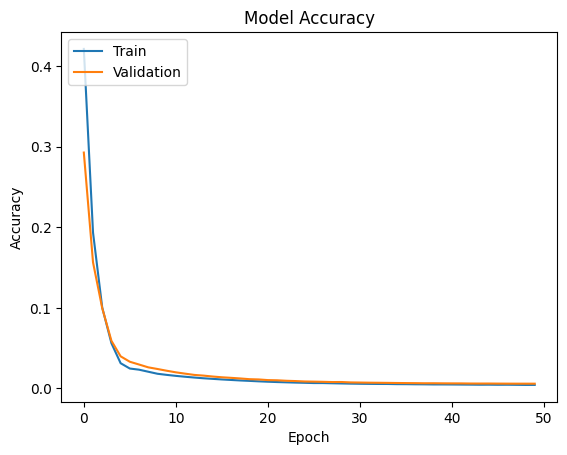

In [72]:
plt.plot(history.history['mse'])
plt.plot(history.history['val_mse'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

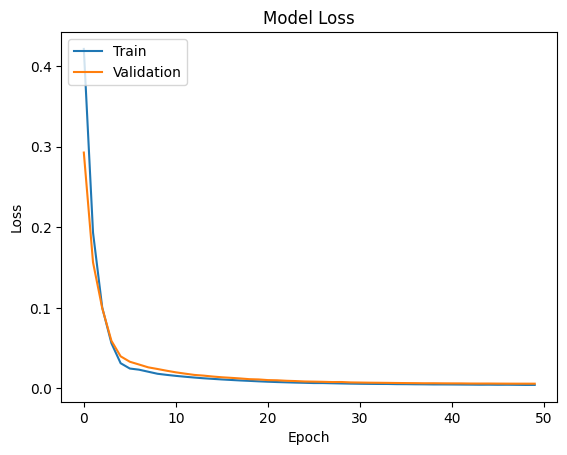

In [73]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()